# Klasifikasi Dengan LDA


In [25]:
!pip install plotly


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [26]:
!pip install -q nltk contractions emoji pyspellchecker Sastrawi


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [27]:
!pip install gensim



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [28]:
import re
import sys
import time
import string
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from spellchecker import SpellChecker
import contractions
import emoji
from gensim.models import Word2Vec, FastText
from gensim import corpora, models
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm import tqdm
warnings.filterwarnings('ignore')

In [29]:
nltk.download("punkt")
nltk.download("punkt_tab")

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Crawling Berita

In [30]:
def berita(categories, pages_per_category=1):
    start_time = time.time()  # mulai hitung waktu

    BASE_URL = "https://www.tempo.co/indeks?page={}&category=rubrik&rubric_slug={}"

    data = {
        "id_berita": [],
        "judul_berita": [],
        "isi_berita": [],
        "kategori_berita": []
    }

    for cat_id, cat in enumerate(categories, start=1):
        for page in range(1, pages_per_category+1):
            url = BASE_URL.format(page, cat)
            r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
            soup = BeautifulSoup(r.text, "html.parser")

            articles = soup.select("figure figcaption a")
            for a in articles:
                link = "https://www.tempo.co" + a["href"]
                title = a.get_text(strip=True)

                id_match = re.search(r"-(\d+)$", link)
                berita_id = id_match.group(1) if id_match else None

                try:
                    content = get_article_content(link)
                except:
                    content = ""

                data["id_berita"].append(berita_id)
                data["judul_berita"].append(title)
                data["isi_berita"].append(content)
                data["kategori_berita"].append(cat)

            print_progress2(cat, page, pages_per_category)

    df = pd.DataFrame(data)
    df.to_csv("tempo_berita.csv", index=False, encoding="utf-8-sig")

    end_time = time.time()
    elapsed = int(end_time - start_time)
    jam, sisa = divmod(elapsed, 3600)
    menit, detik = divmod(sisa, 60)

    # summary
    print("\n✅ Seluruh data berhasil dikumpulkan!")
    print(f"📊 Total entri: {len(df)}")
    print(f"⏱️ Waktu eksekusi: {jam} jam {menit} menit {detik} detik")

    return None

In [31]:
berita = pd.read_csv("tempo_berita.csv")
berita

,id_berita,judul_berita,isi_berita,kategori_berita
0,2070560,Habis Demo Berujung Rusuh Terbitlah Siskamling,ATAP berukuran 5 x 3 meter menaungi Jalan Kema...,politik
1,2070554,Siskamling: Warisan Orde Baru yang Dihidupkan ...,MENTERI Dalam NegeriTito Karnavianmeminta peme...,politik
2,2070547,6.118 Aparat Gabungan Disiagakan Jaga Demo di ...,ASOSIASI pengemudiojekonlineGarda Indonesia be...,politik
3,2070538,Prabowo Dikabarkan akan Melakukan Reshuffle Ka...,PRESIDENPrabowo Subiantodikabarkan akan melaku...,politik
4,2070529,Fakta Terbaru Soal Ompreng MBG Diduga Mengandu...,ISU dugaanompreng atau wadah makan bergizi gra...,politik
...,...,...,...,...
215,2070442,Kejagung Periksa Anak Jusuf Hamka soal Dugaan ...,"Kejaksaan Agung memeriksa Fitria Yusuf, anak p...",ekonomi
216,2070429,"Martubung, Kawasan Padat Penduduk di Medan yan...","TAMAN kolam retensi, tepat di samping Perumnas...",ekonomi
217,2070424,KAI Siapkan Promo Tarif Flat Rp 80 Ribu saat H...,PT KERETA Api Indonesia (Persero) atauKAIsecar...,ekonomi
218,2070420,KKP Bilang Penguggah Video Tanggul Beton di Ci...,NaN,ekonomi


## Fungsi cleaning dengan emoji


In [32]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()  # huruf kecil
    text = emoji.demojize(text)  # ubah emoji jadi teks, misal 😀 -> :grinning_face:
    text = re.sub(r'\d+', '', text)  # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = re.sub(r'\W', ' ', text)  # hapus karakter non-kata
    text = BeautifulSoup(text, "html.parser").get_text()  # hapus tag HTML
    text = re.sub(r'\s+', ' ', text).strip()  # normalisasi spasi
    return text

# Baca CSV
tempo_df = pd.read_csv("tempo_berita.csv", dtype=str).fillna("")

# Terapkan langsung ke kolom target
tempo_df["isi_berita_clean"] = tempo_df["isi_berita"].apply(clean_text)

# Cleaning kolom target
tempo_df["isi_berita_clean"] = tempo_df["isi_berita"].apply(clean_text)

In [33]:
print("\nBerita (tempo_berita):")
tempo_df[["isi_berita", "isi_berita_clean"]].head(10)


Berita (tempo_berita):


,isi_berita,isi_berita_clean
0,ATAP berukuran 5 x 3 meter menaungi Jalan Kema...,atap berukuran x meter menaungi jalan kemanggi...
1,MENTERI Dalam NegeriTito Karnavianmeminta peme...,menteri dalam negeritito karnavianmeminta peme...
2,ASOSIASI pengemudiojekonlineGarda Indonesia be...,asosiasi pengemudiojekonlinegarda indonesia be...
3,PRESIDENPrabowo Subiantodikabarkan akan melaku...,presidenprabowo subiantodikabarkan akan melaku...
4,ISU dugaanompreng atau wadah makan bergizi gra...,isu dugaanompreng atau wadah makan bergizi gra...
5,MENTERI Koordinator Bidang PerekonomianAirlang...,menteri koordinator bidang perekonomianairlang...
6,MAHKAMAHKonstitusi atauMKakan membacakan putus...,mahkamahkonstitusi ataumkakan membacakan putus...
7,LEMBAGAPengelola Dana Pendidikan atauLPDPmeman...,lembagapengelola dana pendidikan ataulpdpmeman...
8,ASOSIASIPengemudi OjekOnlineGarda Indonesia ak...,asosiasipengemudi ojekonlinegarda indonesia ak...
9,KOMISIPemilihan Umum(KPU) membatalkan aturan m...,komisipemilihan umumkpu membatalkan aturan men...


In [34]:
# Tokenisasi untuk PTA
tempo_df["isi_berita_tokens"] = tempo_df["isi_berita_clean"].apply(word_tokenize)

In [35]:
print("\nBerita (isi_berita_tokens):")
tempo_df[["isi_berita_clean", "isi_berita_tokens"]].head(10)


Berita (isi_berita_tokens):


,isi_berita_clean,isi_berita_tokens
0,atap berukuran x meter menaungi jalan kemanggi...,"[atap, berukuran, x, meter, menaungi, jalan, k..."
1,menteri dalam negeritito karnavianmeminta peme...,"[menteri, dalam, negeritito, karnavianmeminta,..."
2,asosiasi pengemudiojekonlinegarda indonesia be...,"[asosiasi, pengemudiojekonlinegarda, indonesia..."
3,presidenprabowo subiantodikabarkan akan melaku...,"[presidenprabowo, subiantodikabarkan, akan, me..."
4,isu dugaanompreng atau wadah makan bergizi gra...,"[isu, dugaanompreng, atau, wadah, makan, bergi..."
5,menteri koordinator bidang perekonomianairlang...,"[menteri, koordinator, bidang, perekonomianair..."
6,mahkamahkonstitusi ataumkakan membacakan putus...,"[mahkamahkonstitusi, ataumkakan, membacakan, p..."
7,lembagapengelola dana pendidikan ataulpdpmeman...,"[lembagapengelola, dana, pendidikan, ataulpdpm..."
8,asosiasipengemudi ojekonlinegarda indonesia ak...,"[asosiasipengemudi, ojekonlinegarda, indonesia..."
9,komisipemilihan umumkpu membatalkan aturan men...,"[komisipemilihan, umumkpu, membatalkan, aturan..."


## Stopwords

In [36]:
# Stopwords untuk bahasa Indonesia
stop_words_id = set(stopwords.words('indonesian'))

# Filter stopwords di PTA
tempo_df["isi_berita_filtered"] = tempo_df["isi_berita_tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words_id]
)

In [37]:
print("\nBerita (isi_berita_filtered):")
tempo_df[["isi_berita_tokens", "isi_berita_filtered"]].head(10)


Berita (isi_berita_filtered):


,isi_berita_tokens,isi_berita_filtered
0,"[atap, berukuran, x, meter, menaungi, jalan, k...","[atap, berukuran, x, meter, menaungi, jalan, k..."
1,"[menteri, dalam, negeritito, karnavianmeminta,...","[menteri, negeritito, karnavianmeminta, pemeri..."
2,"[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia..."
3,"[presidenprabowo, subiantodikabarkan, akan, me...","[presidenprabowo, subiantodikabarkan, melakuka..."
4,"[isu, dugaanompreng, atau, wadah, makan, bergi...","[isu, dugaanompreng, wadah, makan, bergizi, gr..."
5,"[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair..."
6,"[mahkamahkonstitusi, ataumkakan, membacakan, p...","[mahkamahkonstitusi, ataumkakan, membacakan, p..."
7,"[lembagapengelola, dana, pendidikan, ataulpdpm...","[lembagapengelola, dana, pendidikan, ataulpdpm..."
8,"[asosiasipengemudi, ojekonlinegarda, indonesia...","[asosiasipengemudi, ojekonlinegarda, indonesia..."
9,"[komisipemilihan, umumkpu, membatalkan, aturan...","[komisipemilihan, umumkpu, membatalkan, aturan..."


In [38]:
factory = StemmerFactory()
indo_stemmer = factory.create_stemmer()

tempo_df["isi_berita_stemmed"] = tempo_df["isi_berita_filtered"].apply(
    lambda tokens: [indo_stemmer.stem(word) for word in tokens]
)

In [39]:
print("\nBerita - Stemming & Lemmatization (abstrak_id):")
tempo_df[["isi_berita_filtered", "isi_berita_stemmed"]].head(10)


Berita - Stemming & Lemmatization (abstrak_id):


,isi_berita_filtered,isi_berita_stemmed
0,"[atap, berukuran, x, meter, menaungi, jalan, k...","[atap, ukur, x, meter, taung, jalan, manggis, ..."
1,"[menteri, negeritito, karnavianmeminta, pemeri...","[menteri, negeritito, karnavianmeminta, perint..."
2,"[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia..."
3,"[presidenprabowo, subiantodikabarkan, melakuka...","[presidenprabowo, subiantodikabarkan, melakuka..."
4,"[isu, dugaanompreng, wadah, makan, bergizi, gr...","[isu, dugaanompreng, wadah, makan, gizi, grati..."
5,"[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair..."
6,"[mahkamahkonstitusi, ataumkakan, membacakan, p...","[mahkamahkonstitusi, ataumkakan, baca, putus, ..."
7,"[lembagapengelola, dana, pendidikan, ataulpdpm...","[lembagapengelola, dana, didik, ataulpdpmemang..."
8,"[asosiasipengemudi, ojekonlinegarda, indonesia...","[asosiasipengemudi, ojekonlinegarda, indonesia..."
9,"[komisipemilihan, umumkpu, membatalkan, aturan...","[komisipemilihan, umumkpu, batal, atur, batas,..."


## Fungsi expand kontraksi bahasa Indonesia


In [40]:
def expand_indonesian_contractions(text):
  contractions_dict = {
      "gak": "tidak", "ga": "tidak", "nggak": "tidak", "enggak": "tidak", "ngga": "tidak", "gk": "tidak", "tdk": "tidak", "tk": "tidak",
      "gue": "saya", "gw": "saya", "gua": "saya", "sy": "saya", "aq": "saya", "q": "saya", "ane": "saya",
      "lu": "kamu", "loe": "kamu", "lo": "kamu", "km": "kamu", "kmu": "kamu", "elu": "kamu",
      "dah": "sudah", "udah": "sudah", "sdh": "sudah", "udh": "sudah",
      "blm": "belum", "td": "tadi", "ntar": "nanti", "skr": "sekarang", "skrg": "sekarang", "skg": "sekarang",
      "kmrn": "kemarin", "kemrn": "kemarin", "kmarin": "kemarin",
      "aja": "saja", "aj": "saja", "sj": "saja",
      "nih": "ini", "nie": "ini", "ni": "ini", "tuh": "itu", "gtu": "begitu", "gitu": "begitu",
      "trs": "terus", "trus": "terus",
      "yg": "yang", "utk": "untuk", "dlm": "dalam", "dr": "dari", "dg": "dengan", "jd": "jadi", "jg": "juga",
      "krn": "karena", "tp": "tetapi", "tpi": "tetapi", "sm": "sama", "thd": "terhadap",
      "dll": "dan lain-lain", "dsb": "dan sebagainya", "dst": "dan seterusnya",
      "banget": "sekali", "bgt": "sekali", "sgt": "sangat", "sngt": "sangat",
      "lg": "sedang", "sdg": "sedang",
      "dl": "dulu", "pls": "tolong", "tolongin": "tolong", "plis": "tolong",
      "wkwk": "tertawa", "wkwkwk": "tertawa", "hehe": "tertawa kecil", "hihi": "tertawa kecil",
      "btw": "ngomong-ngomong", "imo": "menurut saya", "imho": "menurut saya", "cmiiw": "koreksi jika saya salah",
      "idk": "saya tidak tahu", "jk": "hanya bercanda",
      "ok": "baik", "oke": "baik", "okey": "baik", "sip": "baik",
      "ciyus": "serius", "serem": "menyeramkan",
      "kl": "kalau", "klo": "kalau", "klu": "kalau",
      "spy": "supaya", "spya": "supaya",
      "bbrp": "beberapa", "tsb": "tersebut", "trsbt": "tersebut",
      "dpt": "dapat", "bs": "bisa", "bsa": "bisa",
      "stlh": "setelah", "sblm": "sebelum",

      "mnj": "manajemen", "man": "manajemen", "mgt": "management",
      "org": "organisasi", "org2": "organisasi", "orgzt": "organisasi",
      "str": "struktur", "stkt": "struktur",
      "ldr": "leader", "ldrshp": "leadership", "pimp": "pimpinan", "pemimp": "pemimpin",
      "pln": "perencanaan", "renc": "perencanaan", "plan": "perencanaan",
      "orgz": "organizing", "orgzn": "organisasi",
      "dir": "directing", "pgn": "pengarahan",
      "cnt": "control", "cont": "control", "ctrl": "kontrol", "pengend": "pengendalian",
      "eff": "efisiensi", "effct": "efektivitas",
      "sdm": "sumber daya manusia", "hr": "human resource", "hrd": "human resource development",
      "res": "resource", "rsc": "resource", "sda": "sumber daya alam",
      "inv": "investasi", "invt": "investasi",
      "pmas": "pemasaran", "mkt": "marketing", "mktg": "marketing",
      "prod": "produksi", "prdks": "produksi",
      "fin": "finance", "keu": "keuangan", "akut": "akuntansi", "acct": "akuntansi",
      "ris": "risiko", "rsko": "risiko",
      "anal": "analisis", "eval": "evaluasi",
      "strtg": "strategi", "stg": "strategi",
      "ops": "operasi", "opr": "operasional", "oprs": "operasional",
      "bsc": "balanced scorecard", "swot": "analisis swot", "pest": "analisis pest",
      "csr": "corporate social responsibility", "gcn": "good corporate governance",
      "qm": "quality management", "iso": "standar iso",
      "kpi": "key performance indicator", "indik": "indikator",
      "knowl": "knowledge management", "kmgt": "knowledge management",
      "chg": "change management", "innv": "inovasi",
      "cnfl": "konflik", "cnflt": "konflik",
      "krj": "kerja", "tm": "tim", "tmwrk": "kerja sama tim",
      "cst": "cost", "faktorfaktor": "faktor", "bya": "biaya",
      "val": "nilai", "valu": "value",
      "proj": "proyek", "prjk": "proyek",

      "med": "medis", "obat2": "obat-obatan", "rs": "rumah sakit",
      "dok": "dokter", "drg": "dokter gigi", "prof": "profesor",
      "pt": "perguruan tinggi", "univ": "universitas", "fak": "fakultas",
      "skripsi": "skripsi", "tesis": "tesis", "disertasi": "disertasi",
      "mhs": "mahasiswa", "mhsw": "mahasiswa"
  }


  pattern = r'\b(' + '|'.join(re.escape(key) for key in contractions_dict.keys()) + r')\b'

  def replace_match(match):
      return contractions_dict[match.group(0).lower()]

  expanded_text = re.sub(pattern, replace_match, text, flags=re.IGNORECASE)
  return expanded_text


tempo_df["isi_berita_expanded"] = tempo_df["isi_berita_stemmed"].apply(
    lambda tokens: expand_indonesian_contractions(" ".join(tokens)).split()
)


In [41]:
print("\nBerita - Isi berita (expanded):")
tempo_df[["isi_berita_stemmed", "isi_berita_expanded"]].head(10)


Berita - Isi berita (expanded):


,isi_berita_stemmed,isi_berita_expanded
0,"[atap, ukur, x, meter, taung, jalan, manggis, ...","[atap, ukur, x, meter, taung, jalan, manggis, ..."
1,"[menteri, negeritito, karnavianmeminta, perint...","[menteri, negeritito, karnavianmeminta, perint..."
2,"[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia..."
3,"[presidenprabowo, subiantodikabarkan, melakuka...","[presidenprabowo, subiantodikabarkan, melakuka..."
4,"[isu, dugaanompreng, wadah, makan, gizi, grati...","[isu, dugaanompreng, wadah, makan, gizi, grati..."
5,"[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair..."
6,"[mahkamahkonstitusi, ataumkakan, baca, putus, ...","[mahkamahkonstitusi, ataumkakan, baca, putus, ..."
7,"[lembagapengelola, dana, didik, ataulpdpmemang...","[lembagapengelola, dana, didik, ataulpdpmemang..."
8,"[asosiasipengemudi, ojekonlinegarda, indonesia...","[asosiasipengemudi, ojekonlinegarda, indonesia..."
9,"[komisipemilihan, umumkpu, batal, atur, batas,...","[komisipemilihan, umumkpu, batal, atur, batas,..."


In [43]:
# Inisialisasi SpellChecker kosong
spell = SpellChecker(language=None)

# Load kamus Indonesia dari file
with open("00-indonesian-wordlist.lst", "r", encoding="latin-1") as f:
    indo_words = [line.strip() for line in f.readlines()]

spell.word_frequency.load_words(indo_words)

# Fungsi untuk koreksi kata
def correct_word(word):
    corr = spell.correction(word)
    return corr if corr is not None else word

# Terapkan spellcheck ke setiap baris dengan progress bar
corrected_texts = []
for tokens in tqdm(tempo_df["isi_berita_expanded"], desc="Spellchecking", unit="row"):
    corrected = [correct_word(word) for word in tokens]
    corrected_texts.append(corrected)

tempo_df["isi_berita_spellchecked"] = corrected_texts

Spellchecking: 100%|██████████| 220/220 [24:21<00:00,  6.64s/row]


In [44]:
print("\nBerita (Cek Ejaan):")
tempo_df[["isi_berita_expanded", "isi_berita_spellchecked"]].head(10)


Berita (Cek Ejaan):


,isi_berita_expanded,isi_berita_spellchecked
0,"[atap, ukur, x, meter, taung, jalan, manggis, ...","[atap, ukur, x, meter, taung, jalan, manggis, ..."
1,"[menteri, negeritito, karnavianmeminta, perint...","[menteri, negeritito, karnavianmeminta, perint..."
2,"[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia..."
3,"[presidenprabowo, subiantodikabarkan, melakuka...","[presidenprabowo, subiantodikabarkan, melakuka..."
4,"[isu, dugaanompreng, wadah, makan, gizi, grati...","[isu, dugaanompreng, wadah, makan, gizi, grati..."
5,"[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair..."
6,"[mahkamahkonstitusi, ataumkakan, baca, putus, ...","[mahkamahkonstitusi, ataumkakan, baca, putus, ..."
7,"[lembagapengelola, dana, didik, ataulpdpmemang...","[lembagapengelola, dana, didik, ataulpdpmemang..."
8,"[asosiasipengemudi, ojekonlinegarda, indonesia...","[asosiasipengemudi, ojekonlinegarda, indonesia..."
9,"[komisipemilihan, umumkpu, batal, atur, batas,...","[komisipemilihan, umumkan, batal, atur, batas,..."


## Pilih kolom yang ingin disimpan

In [45]:
cols_to_save = [
    "id_berita",
    "judul_berita",
    "isi_berita",
    "kategori_berita",
    "isi_berita_clean",
    "isi_berita_tokens",
    "isi_berita_filtered",
    "isi_berita_stemmed",
    "isi_berita_expanded",
    "isi_berita_spellchecked"
]

# Simpan ke CSV
tempo_df[cols_to_save].to_csv("tempo_processed.csv", index=False, encoding="utf-8-sig")

print("File berhasil disimpan sebagai tempo_processed.csv")


File berhasil disimpan sebagai tempo_processed.csv


In [46]:
tempo_df_prs= pd.read_csv("tempo_processed.csv")
tempo_df_prs

,id_berita,judul_berita,isi_berita,kategori_berita,isi_berita_clean,isi_berita_tokens,isi_berita_filtered,isi_berita_stemmed,isi_berita_expanded,isi_berita_spellchecked
0,2070560,Habis Demo Berujung Rusuh Terbitlah Siskamling,ATAP berukuran 5 x 3 meter menaungi Jalan Kema...,politik,atap berukuran x meter menaungi jalan kemanggi...,"['atap', 'berukuran', 'x', 'meter', 'menaungi'...","['atap', 'berukuran', 'x', 'meter', 'menaungi'...","['atap', 'ukur', 'x', 'meter', 'taung', 'jalan...","['atap', 'ukur', 'x', 'meter', 'taung', 'jalan...","['atap', 'ukur', 'x', 'meter', 'taung', 'jalan..."
1,2070554,Siskamling: Warisan Orde Baru yang Dihidupkan ...,MENTERI Dalam NegeriTito Karnavianmeminta peme...,politik,menteri dalam negeritito karnavianmeminta peme...,"['menteri', 'dalam', 'negeritito', 'karnavianm...","['menteri', 'negeritito', 'karnavianmeminta', ...","['menteri', 'negeritito', 'karnavianmeminta', ...","['menteri', 'negeritito', 'karnavianmeminta', ...","['menteri', 'negeritito', 'karnavianmeminta', ..."
2,2070547,6.118 Aparat Gabungan Disiagakan Jaga Demo di ...,ASOSIASI pengemudiojekonlineGarda Indonesia be...,politik,asosiasi pengemudiojekonlinegarda indonesia be...,"['asosiasi', 'pengemudiojekonlinegarda', 'indo...","['asosiasi', 'pengemudiojekonlinegarda', 'indo...","['asosiasi', 'pengemudiojekonlinegarda', 'indo...","['asosiasi', 'pengemudiojekonlinegarda', 'indo...","['asosiasi', 'pengemudiojekonlinegarda', 'indo..."
3,2070538,Prabowo Dikabarkan akan Melakukan Reshuffle Ka...,PRESIDENPrabowo Subiantodikabarkan akan melaku...,politik,presidenprabowo subiantodikabarkan akan melaku...,"['presidenprabowo', 'subiantodikabarkan', 'aka...","['presidenprabowo', 'subiantodikabarkan', 'mel...","['presidenprabowo', 'subiantodikabarkan', 'mel...","['presidenprabowo', 'subiantodikabarkan', 'mel...","['presidenprabowo', 'subiantodikabarkan', 'mel..."
4,2070529,Fakta Terbaru Soal Ompreng MBG Diduga Mengandu...,ISU dugaanompreng atau wadah makan bergizi gra...,politik,isu dugaanompreng atau wadah makan bergizi gra...,"['isu', 'dugaanompreng', 'atau', 'wadah', 'mak...","['isu', 'dugaanompreng', 'wadah', 'makan', 'be...","['isu', 'dugaanompreng', 'wadah', 'makan', 'gi...","['isu', 'dugaanompreng', 'wadah', 'makan', 'gi...","['isu', 'dugaanompreng', 'wadah', 'makan', 'gi..."
...,...,...,...,...,...,...,...,...,...,...
215,2070442,Kejagung Periksa Anak Jusuf Hamka soal Dugaan ...,"Kejaksaan Agung memeriksa Fitria Yusuf, anak p...",ekonomi,kejaksaan agung memeriksa fitria yusuf anak pe...,"['kejaksaan', 'agung', 'memeriksa', 'fitria', ...","['kejaksaan', 'agung', 'memeriksa', 'fitria', ...","['jaksa', 'agung', 'periksa', 'fitria', 'yusuf...","['jaksa', 'agung', 'periksa', 'fitria', 'yusuf...","['jaksa', 'agung', 'periksa', 'fitri', 'kusuf'..."
216,2070429,"Martubung, Kawasan Padat Penduduk di Medan yan...","TAMAN kolam retensi, tepat di samping Perumnas...",ekonomi,taman kolam retensi tepat di samping perumnas ...,"['taman', 'kolam', 'retensi', 'tepat', 'di', '...","['taman', 'kolam', 'retensi', 'samping', 'peru...","['taman', 'kolam', 'retensi', 'samping', 'peru...","['taman', 'kolam', 'retensi', 'samping', 'peru...","['taman', 'kolam', 'retensi', 'samping', 'peru..."
217,2070424,KAI Siapkan Promo Tarif Flat Rp 80 Ribu saat H...,PT KERETA Api Indonesia (Persero) atauKAIsecar...,ekonomi,pt kereta api indonesia persero ataukaisecara ...,"['pt', 'kereta', 'api', 'indonesia', 'persero'...","['pt', 'kereta', 'api', 'indonesia', 'persero'...","['pt', 'kereta', 'api', 'indonesia', 'persero'...","['perguruan', 'tinggi', 'kereta', 'api', 'indo...","['perguruan', 'tinggi', 'kereta', 'api', 'indo..."
218,2070420,KKP Bilang Penguggah Video Tanggul Beton di Ci...,NaN,ekonomi,NaN,[],[],[],[],[]


## Hitung frekuensi kemunculan setiap kata

In [47]:
from collections import Counter
import numpy as np
all_tokens = [word for tokens in tempo_df["isi_berita_spellchecked"] for word in tokens]

# Hitung frekuensi kemunculan setiap kata
word_freq = Counter(all_tokens)

# Ambil 20 kata yang paling sering muncul
common_words = word_freq.most_common(10)

print("=== 10 Kata Terbanyak ===")
for word, freq in common_words:
    print(f"{word} : {freq}")

# Informasi tambahan
total_words = len(all_tokens)                       # jumlah total kata
unique_words = len(word_freq)                       # jumlah kata unik
avg_word_len = np.mean([len(word) for word in all_tokens])  # rata-rata panjang kata
avg_words_per_data = np.mean([len(tokens) for tokens in tempo_df["isi_berita_spellchecked"]])  # rata-rata kata per data
longest_word = max(all_tokens, key=len)             # kata terpanjang
longest_word_len = len(longest_word)

print("\n=== Statistik Tambahan ===")
print(f"Jumlah total kata       : {total_words}")
print(f"Jumlah kata unik        : {unique_words}")
print(f"Rata-rata panjang kata  : {avg_word_len:.2f} karakter")
print(f"Rata-rata kata per data : {avg_words_per_data:.2f} kata")


=== 10 Kata Terbanyak ===
september : 449
presiden : 321
menteri : 311
pilih : 300
jakarta : 267
polisi : 247
indonesia : 239
hukum : 221
publik : 217
komisi : 217

=== Statistik Tambahan ===
Jumlah total kata       : 46702
Jumlah kata unik        : 5344
Rata-rata panjang kata  : 6.02 karakter
Rata-rata kata per data : 212.28 kata


## Konversi hasil frekuensi kata ke DataFrame

In [48]:
word_freq_df = pd.DataFrame(word_freq.items(), columns=["kata", "jumlah"])

# Urutkan berdasarkan jumlah kemunculan kata (dari terbesar ke terkecil)
word_freq_df = word_freq_df.sort_values(by="jumlah", ascending=False).reset_index(drop=True)

# Simpan hasil ke file CSV
word_freq_df.to_csv("tempo_word_frequency.csv", index=False, encoding="utf-8-sig")

print("\nFile berhasil disimpan sebagai tempo_word_frequency.csv.")



File berhasil disimpan sebagai tempo_word_frequency.csv.


## TF-IDF

In [49]:
tempo_df_wfq = pd.read_csv("tempo_word_frequency.csv")
print(tempo_df_wfq.head(10))

        kata  jumlah
0  september     449
1   presiden     321
2    menteri     311
3      pilih     300
4    jakarta     267
5     polisi     247
6  indonesia     239
7      hukum     221
8     komisi     217
9     publik     217


In [50]:
df = pd.read_csv('tempo_word_frequency.csv')

In [51]:
print(tempo_df.columns)

Index(['id_berita', 'judul_berita', 'isi_berita', 'kategori_berita',
       'isi_berita_clean', 'isi_berita_tokens', 'isi_berita_filtered',
       'isi_berita_stemmed', 'isi_berita_expanded', 'isi_berita_spellchecked'],
      dtype='object')


## Membuat TF-IDF Vectorizer

In [52]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(tempo_df['isi_berita_clean'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

In [53]:
print("\nTF-IDF shape:", tfidf_df.shape)
print(tfidf_df.head())


TF-IDF shape: (220, 7925)
   aam  abad  abai     abdul  abdullah  abdurrahman  abjan  abri  absen  \
0  0.0   0.0   0.0  0.000000       0.0          0.0    0.0   0.0    0.0   
1  0.0   0.0   0.0  0.000000       0.0          0.0    0.0   0.0    0.0   
2  0.0   0.0   0.0  0.000000       0.0          0.0    0.0   0.0    0.0   
3  0.0   0.0   0.0  0.034848       0.0          0.0    0.0   0.0    0.0   
4  0.0   0.0   0.0  0.000000       0.0          0.0    0.0   0.0    0.0   

   abuabu  ...  zaman  zat  zeed  zero  ziarah  zionisme  zona  zoom  \
0     0.0  ...    0.0  0.0   0.0   0.0     0.0       0.0   0.0   0.0   
1     0.0  ...    0.0  0.0   0.0   0.0     0.0       0.0   0.0   0.0   
2     0.0  ...    0.0  0.0   0.0   0.0     0.0       0.0   0.0   0.0   
3     0.0  ...    0.0  0.0   0.0   0.0     0.0       0.0   0.0   0.0   
4     0.0  ...    0.0  0.0   0.0   0.0     0.0       0.0   0.0   0.0   

   zulfikar  zulkifli  
0       0.0       0.0  
1       0.0       0.0  
2       0.0      

## Word Embedding

In [54]:
corpus = []
for col in tempo_df['isi_berita_clean']:
    word_list = col.split(" ")
    corpus.append(word_list)

# Word2Vec dengan ukuran vektor 50
model = Word2Vec(corpus, min_count=1, vector_size=50, window=5, sg=0)


In [55]:
print("Kata mirip dengan 'presiden':")
print(model.wv.most_similar('presiden', topn=5))

print("\nKata mirip dengan 'data':")
print(model.wv.most_similar('data', topn=5))

# contoh cosmul
print("\nCosmul (presiden + sistem - data):")
print(model.wv.most_similar_cosmul(positive=['presiden', 'sistem'], negative=['data'], topn=5))

# doesnt_match: cari kata yang tidak sesuai konteks
print("\nKata yang tidak cocok dalam ['presiden', 'data', 'sistem', 'informasi']:")
print(model.wv.doesnt_match("presiden data sistem informasi".split()))

# save embeddings
filename = 'pta_embeddings.txt'
model.wv.save_word2vec_format(filename, binary=False)
print(f"\nEmbeddings disimpan ke {filename}")

Kata mirip dengan 'presiden':
[('calon', 0.9982998371124268), ('persyaratan', 0.9977591037750244), ('wakil', 0.9977292418479919), ('dokumen', 0.9960920810699463), ('dikecualikan', 0.9951874017715454)]

Kata mirip dengan 'data':
[('sebagai', 0.9995675086975098), ('terhadap', 0.9995657801628113), ('bisa', 0.9995220303535461), ('dapat', 0.9995108246803284), ('secara', 0.999509334564209)]

Cosmul (presiden + sistem - data):
[('calon', 0.9964609146118164), ('persyaratan', 0.9964022636413574), ('dokumen', 0.996159553527832), ('wakil', 0.9960313439369202), ('subianto', 0.9959191083908081)]

Kata yang tidak cocok dalam ['presiden', 'data', 'sistem', 'informasi']:
presiden

Embeddings disimpan ke pta_embeddings.txt


In [56]:
class MyTokenizer:
    def fit_transform(self, texts):
        return [str(text).lower().split() for text in texts]

class MeanEmbeddingVectorizer:
    def __init__(self, word2vec_model):
        self.word2vec = word2vec_model
        self.dim = word2vec_model.wv.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_tokenized = MyTokenizer().fit_transform(X)
        embeddings = []
        for words in X_tokenized:
            valid_vectors = [
                self.word2vec.wv[word] for word in words
                if word in self.word2vec.wv
            ]
            if valid_vectors:
                embeddings.append(np.mean(valid_vectors, axis=0))
            else:
                embeddings.append(np.zeros(self.dim))
        return np.array(embeddings)

    def fit_transform(self, X, y=None):
        return self.transform(X)

In [57]:
tempo_df.shape

(220, 10)

In [58]:
tempo_df['tokens'] = tempo_df['isi_berita_clean'].apply(lambda x: str(x).split())
mean_embedding_vectorizer = MeanEmbeddingVectorizer(model)
mean_embedded = mean_embedding_vectorizer.fit_transform(tempo_df['tokens'])


In [59]:
tempo_df['array'] = list(mean_embedded)

In [60]:
tempo_df.head(10)

,id_berita,judul_berita,isi_berita,kategori_berita,isi_berita_clean,isi_berita_tokens,isi_berita_filtered,isi_berita_stemmed,isi_berita_expanded,isi_berita_spellchecked,tokens,array
0,2070560,Habis Demo Berujung Rusuh Terbitlah Siskamling,ATAP berukuran 5 x 3 meter menaungi Jalan Kema...,politik,atap berukuran x meter menaungi jalan kemanggi...,"[atap, berukuran, x, meter, menaungi, jalan, k...","[atap, berukuran, x, meter, menaungi, jalan, k...","[atap, ukur, x, meter, taung, jalan, manggis, ...","[atap, ukur, x, meter, taung, jalan, manggis, ...","[atap, ukur, x, meter, taung, jalan, manggis, ...","[atap, berukuran, x, meter, menaungi, jalan, k...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2070554,Siskamling: Warisan Orde Baru yang Dihidupkan ...,MENTERI Dalam NegeriTito Karnavianmeminta peme...,politik,menteri dalam negeritito karnavianmeminta peme...,"[menteri, dalam, negeritito, karnavianmeminta,...","[menteri, negeritito, karnavianmeminta, pemeri...","[menteri, negeritito, karnavianmeminta, perint...","[menteri, negeritito, karnavianmeminta, perint...","[menteri, negeritito, karnavianmeminta, perint...","[menteri, dalam, negeritito, karnavianmeminta,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2070547,6.118 Aparat Gabungan Disiagakan Jaga Demo di ...,ASOSIASI pengemudiojekonlineGarda Indonesia be...,politik,asosiasi pengemudiojekonlinegarda indonesia be...,"[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia...","[asosiasi, pengemudiojekonlinegarda, indonesia...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2070538,Prabowo Dikabarkan akan Melakukan Reshuffle Ka...,PRESIDENPrabowo Subiantodikabarkan akan melaku...,politik,presidenprabowo subiantodikabarkan akan melaku...,"[presidenprabowo, subiantodikabarkan, akan, me...","[presidenprabowo, subiantodikabarkan, melakuka...","[presidenprabowo, subiantodikabarkan, melakuka...","[presidenprabowo, subiantodikabarkan, melakuka...","[presidenprabowo, subiantodikabarkan, melakuka...","[presidenprabowo, subiantodikabarkan, akan, me...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2070529,Fakta Terbaru Soal Ompreng MBG Diduga Mengandu...,ISU dugaanompreng atau wadah makan bergizi gra...,politik,isu dugaanompreng atau wadah makan bergizi gra...,"[isu, dugaanompreng, atau, wadah, makan, bergi...","[isu, dugaanompreng, wadah, makan, bergizi, gr...","[isu, dugaanompreng, wadah, makan, gizi, grati...","[isu, dugaanompreng, wadah, makan, gizi, grati...","[isu, dugaanompreng, wadah, makan, gizi, grati...","[isu, dugaanompreng, atau, wadah, makan, bergi...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,2070522,Program Magang Nasional untuk Fresh Graduate D...,MENTERI Koordinator Bidang PerekonomianAirlang...,politik,menteri koordinator bidang perekonomianairlang...,"[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair...","[menteri, koordinator, bidang, perekonomianair...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,2070513,Hari Ini MK Bacakan Putusan Lima Gugatan Uji F...,MAHKAMAHKonstitusi atauMKakan membacakan putus...,politik,mahkamahkonstitusi ataumkakan membacakan putus...,"[mahkamahkonstitusi, ataumkakan, membacakan, p...","[mahkamahkonstitusi, ataumkakan, membacakan, p...","[mahkamahkonstitusi, ataumkakan, baca, putus, ...","[mahkamahkonstitusi, ataumkakan, baca, putus, ...","[mahkamahkonstitusi, ataumkakan, baca, putus, ...","[mahkamahkonstitusi, ataumkakan, membacakan, p...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,2070512,LPDP Pangkas Kuota Penerima Beasiswa untuk 202...,LEMBAGAPengelola Dana Pendidikan atau

In [61]:
tempo_df['embedding_length'] = tempo_df['array'].str.len()

In [62]:
print(tempo_df['embedding_length'])

0      50
1      50
2      50
3      50
4      50
       ..
215    50
216    50
217    50
218    50
219    50
Name: embedding_length, Length: 220, dtype: int64


In [63]:
tempo_df.shape

(220, 13)

In [64]:
num_features = len(tempo_df['array'].iloc[0])  # asumsi semua list punya panjang sama
columns = [f'f{i+1}' for i in range(num_features)]

# Inisialisasi dictionary untuk menampung data per kolom
data_dict = {col: [] for col in columns}

# Looping setiap baris di kolom 'embedding'
for embedding_list in tempo_df['array']:
    for i, value in enumerate(embedding_list):
        data_dict[f'f{i+1}'].append(value)

# Buat DataFrame dari dictionary
embedding_df = pd.DataFrame(data_dict)

print(embedding_df)

      f1   f2   f3   f4   f5   f6   f7   f8   f9  f10  ...  f41  f42  f43  \
0    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
..   ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
215  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
216  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
217  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
218  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
219  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

     f44  f45  f46  f47  f48  f49  f50  
0    0.0  0.0  0.0  0.0  0.0  0.0 

In [65]:
embedding_df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
216,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
218,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Klasifikasi LDA

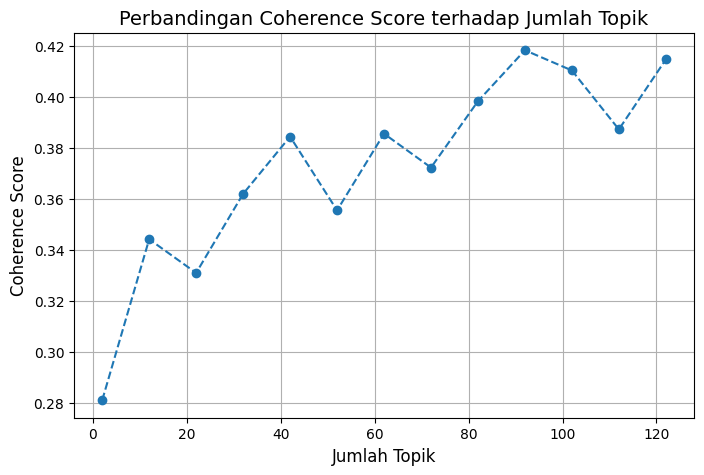

✅ Model terbaik memiliki 92 topik
Coherence Score terbaik: 0.4184569067350968


In [66]:
if 'isi_berita_tokens' not in tempo_df.columns:
    tempo_df['isi_berita_tokens'] = tempo_df['isi_berita_clean'].apply(lambda x: str(x).split())

# Dataset teks tokenized
texts = tempo_df['isi_berita_tokens']

# Buat dictionary dan corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# === Evaluasi jumlah topik optimal ===
coherence_values = []
model_list = []
topic_range = range(2, 130, 10)  # misalnya 2–120 topik

for num_topics in topic_range:
    model = LdaModel(
        corpus=corpus,
        num_topics=num_topics,
        id2word=dictionary,
        random_state=42,
        passes=10,
        iterations=100
    )
    model_list.append(model)
    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

# === Visualisasi Coherence Score ===
plt.figure(figsize=(8, 5))
plt.plot(topic_range, coherence_values, marker='o', linestyle='--')
plt.xlabel("Jumlah Topik", fontsize=12)
plt.ylabel("Coherence Score", fontsize=12)
plt.title("Perbandingan Coherence Score terhadap Jumlah Topik", fontsize=14)
plt.grid(True)
plt.show()

# === Model terbaik ===
optimal_model = model_list[coherence_values.index(max(coherence_values))]
optimal_topics = topic_range[coherence_values.index(max(coherence_values))]

print("✅ Model terbaik memiliki", optimal_topics, "topik")
print("Coherence Score terbaik:", max(coherence_values))



In [67]:
for idx, topic in optimal_model.print_topics(-1):
    print(f"\nTopik {idx+1}: {topic}")


Topik 1: 0.028*"yang" + 0.026*"snpmb" + 0.026*"snbp" + 0.025*"seleksi" + 0.025*"dan" + 0.022*"jalur" + 0.016*"tahun" + 0.015*"untuk" + 0.013*"nasional" + 0.013*"perubahan"

Topik 2: 0.014*"yang" + 0.014*"menjadi" + 0.014*"jalan" + 0.014*"rt" + 0.014*"palmerah" + 0.014*"malam" + 0.014*"pos" + 0.007*"di" + 0.007*"pada" + 0.007*"jakarta"

Topik 3: 0.023*"sampel" + 0.022*"minyak" + 0.020*"dadan" + 0.019*"ompreng" + 0.019*"tersebut" + 0.018*"dan" + 0.018*"mbg" + 0.018*"pada" + 0.015*"hasil" + 0.015*"di"

Topik 4: 0.020*"dan" + 0.017*"di" + 0.015*"pengadilan" + 0.015*"tes" + 0.015*"polri" + 0.014*"ham" + 0.013*"dna" + 0.012*"hakim" + 0.012*"lisa" + 0.012*"perkara"

Topik 5: 0.000*"yang" + 0.000*"keluarga" + 0.000*"tersebut" + 0.000*"itu" + 0.000*"di" + 0.000*"pihak" + 0.000*"negeri" + 0.000*"tidak" + 0.000*"nicholay" + 0.000*"makam"

Topik 6: 0.020*"yang" + 0.018*"di" + 0.018*"dan" + 0.014*"tim" + 0.011*"itu" + 0.010*"dalam" + 0.010*"yusril" + 0.009*"september" + 0.009*"kata" + 0.009*"pembe

In [68]:
dominant_topics = []

for i, doc_bow in enumerate(corpus):
    topics_in_doc = optimal_model.get_document_topics(doc_bow, minimum_probability=0)
    topics_in_doc = sorted(topics_in_doc, key=lambda x: x[1], reverse=True)
    topic_num, prop = topics_in_doc[0]
    dominant_topics.append((topic_num + 1, round(prop, 3)))

df_dominant = pd.DataFrame(dominant_topics, columns=["Topik Dominan", "Proporsi"])

df_result = pd.concat([tempo_df.reset_index(drop=True), df_dominant.reset_index(drop=True)], axis=1)

display(df_result[["judul_berita", "kategori_berita", "Topik Dominan", "Proporsi", "isi_berita_clean"]])

,judul_berita,kategori_berita,Topik Dominan,Proporsi,isi_berita_clean
0,Habis Demo Berujung Rusuh Terbitlah Siskamling,politik,2,0.984,atap berukuran x meter menaungi jalan kemanggi...
1,Siskamling: Warisan Orde Baru yang Dihidupkan ...,politik,88,0.980,menteri dalam negeritito karnavianmeminta peme...
2,6.118 Aparat Gabungan Disiagakan Jaga Demo di ...,politik,15,0.952,asosiasi pengemudiojekonlinegarda indonesia be...
3,Prabowo Dikabarkan akan Melakukan Reshuffle Ka...,politik,75,0.581,presidenprabowo subiantodikabarkan akan melaku...
4,Fakta Terbaru Soal Ompreng MBG Diduga Mengandu...,politik,3,0.596,isu dugaanompreng atau wadah makan bergizi gra...
...,...,...,...,...,...
215,Kejagung Periksa Anak Jusuf Hamka soal Dugaan ...,ekonomi,79,0.995,kejaksaan agung memeriksa fitria yusuf anak pe...
216,"Martubung, Kawasan Padat Penduduk di Medan yan...",ekonomi,8,0.998,taman kolam retensi tepat di samping perumnas ...
217,KAI Siapkan Promo Tarif Flat Rp 80 Ribu saat H...,ekonomi,62,0.998,pt kereta api indonesia persero ataukaisecara ...
218,KKP Bilang Penguggah Video Tanggul Beton di Ci...,ekonomi,1,0.011,


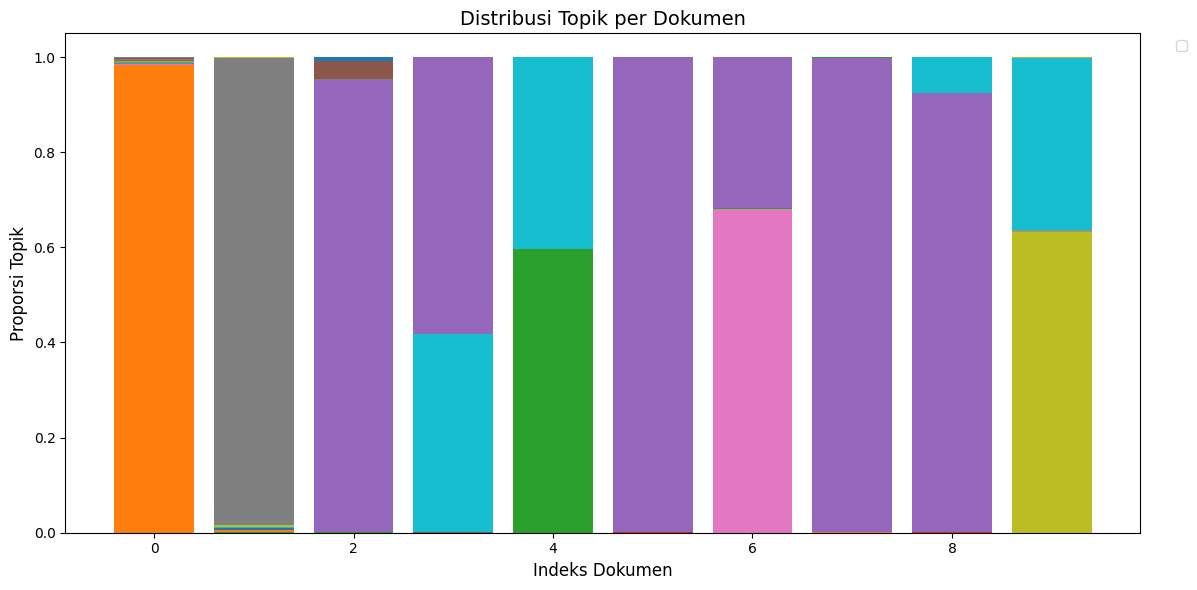

In [69]:
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]
n_docs = min(10, len(topic_distribution))
data = np.array([[prob for _, prob in topic_distribution[i]] for i in range(n_docs)])

# Plot stacked bar
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(n_docs)

for k in range(data.shape[1]):
    ax.bar(range(n_docs), data[:, k], bottom=bottom)
    bottom += data[:, k]

# Judul dan label sumbu
ax.set_title("Distribusi Topik per Dokumen", fontsize=14)
ax.set_xlabel("Indeks Dokumen", fontsize=12)
ax.set_ylabel("Proporsi Topik", fontsize=12)

# Tambahkan legenda di luar area plot agar rapi
ax.legend(bbox_to_anchor=(1.05, 1),)
plt.tight_layout()
plt.show()


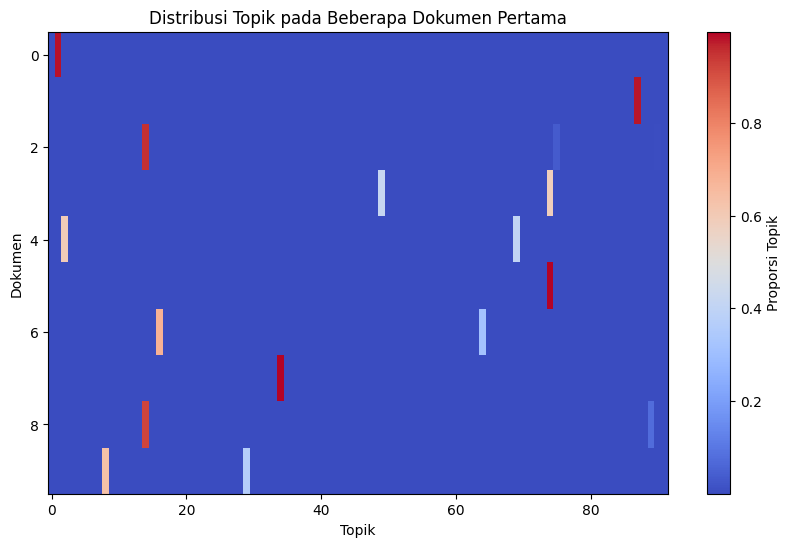

In [70]:
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]

num_docs_to_show = 10
topic_matrix = np.array([[score for _, score in doc] for doc in topic_distribution[:num_docs_to_show]])

plt.figure(figsize=(10, 6))
plt.imshow(topic_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Proporsi Topik')
plt.xlabel('Topik')
plt.ylabel('Dokumen')
plt.title('Distribusi Topik pada Beberapa Dokumen Pertama')
plt.show()

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df_result["isi_berita_clean"].astype(str)  # teks input
y = df_result["kategori_berita"].astype(str)   # label kategori

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)


In [72]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Softmax Regression
softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
softmax_model.fit(X_train, y_train)
y_pred_softmax = softmax_model.predict(X_test)

In [73]:
def evaluasi_model(y_true, y_pred, model_name):
    print(f"\n=== Evaluasi Model: {model_name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### 🔍 Evaluasi Model SVM ###

=== Evaluasi Model: SVM ===
Accuracy : 0.9090909090909091
Precision: 0.8333333333333335
Recall   : 0.9090909090909091

Classification Report:
               precision    recall  f1-score   support

     ekonomi       0.00      0.00      0.00         4
       hukum       1.00      1.00      1.00        20
     politik       0.83      1.00      0.91        20

    accuracy                           0.91        44
   macro avg       0.61      0.67      0.64        44
weighted avg       0.83      0.91      0.87        44



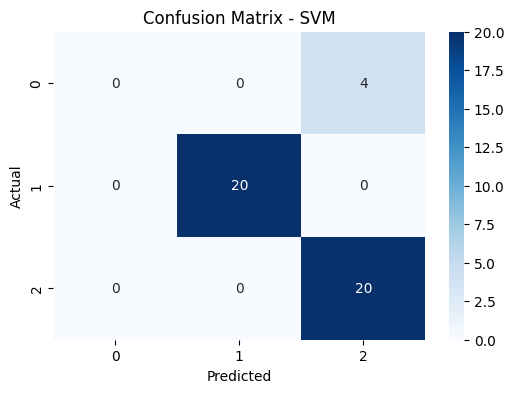

In [74]:
print("### 🔍 Evaluasi Model SVM ###")
evaluasi_model(y_test, y_pred_svm, "SVM")



### 🔍 Evaluasi Model Softmax Regression ###

=== Evaluasi Model: Softmax Regression ===
Accuracy : 0.9090909090909091
Precision: 0.8333333333333335
Recall   : 0.9090909090909091

Classification Report:
               precision    recall  f1-score   support

     ekonomi       0.00      0.00      0.00         4
       hukum       1.00      1.00      1.00        20
     politik       0.83      1.00      0.91        20

    accuracy                           0.91        44
   macro avg       0.61      0.67      0.64        44
weighted avg       0.83      0.91      0.87        44



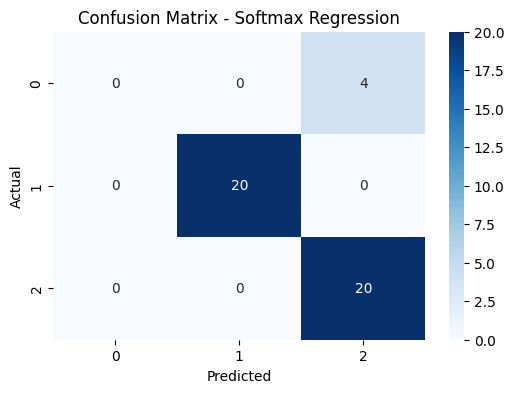

In [75]:
print("\n\n### 🔍 Evaluasi Model Softmax Regression ###")
evaluasi_model(y_test, y_pred_softmax, "Softmax Regression")

In [76]:
coherence_model = CoherenceModel(model=optimal_model, texts=texts, dictionary=dictionary, coherence='c_v')
coherence = coherence_model.get_coherence()
print("Coherence Score (c_v) untuk model terbaik:", coherence)

Coherence Score (c_v) untuk model terbaik: 0.4184569067350968
